# KO Case 02: Lineage-Resolved Simulation vs Experimental Severity 

This notebook compares simulated family-level regulatory signals with experimental knockout severity across multiple developmental lineages.

In this notebook you will:
1. Load curated GLI and SCN summary inputs.
2. Assemble lineage-level summary tables for the main comparison panels.
3. Visualize how simulation-based regulatory strength aligns with experimental KO burden.

Import packages and set deterministic seeds.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Seed set to {SEED}')

Seed set to 0


Set paths and outputs for KO summary reconstruction.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


repo_root = find_repo_root(Path.cwd().resolve())
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'knockout_section'
data_root = repo_root / 'data' / 'knockout'
results_full_root = data_root / 'results_full'
gli_output_root = data_root / 'gene_compensation' / 'gli_output'
scn_output_root = data_root / 'gene_compensation' / 'scn_output'

case_output_root = tutorials_root / 'outputs' / 'knockout_simulation_experimental_panels'
TABLE_DIR = case_output_root / '01_tables'
FIG_DIR = case_output_root / '02_figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

GLI_EFFECTS_PATH = gli_output_root / 'gli_effects_by_celltype.csv'
SCN_EFFECTS_PATH = scn_output_root / 'scn_effects_by_celltype.csv'

required = {'gli_effects': GLI_EFFECTS_PATH, 'scn_effects': SCN_EFFECTS_PATH}
missing = [f'{k}: {v}' for k, v in required.items() if not v.exists()]
if missing:
    raise FileNotFoundError('Missing required files\n' + '\n'.join(missing))


## Step 1: Load curated GLI and SCN summary inputs
Load the precomputed GLI and SCN summary files bundled with the repository assets.


In [ ]:
input_rows = [
    {'summary': 'Simulation output directories', 'file': results_full_root},
    {'summary': 'GLI summary table', 'file': GLI_EFFECTS_PATH},
    {'summary': 'SCN summary table', 'file': SCN_EFFECTS_PATH},
    {'summary': 'GLI lineage-level change table', 'file': gli_output_root / 'Limb#mesenchyme#trajectory' / 'expression_change_results.csv'},
    {'summary': 'SCN lineage-level change table', 'file': scn_output_root / 'Limb#mesenchyme#trajectory' / 'expression_change_results.csv'},
]

print(f'Loaded {len(input_rows)} simulation input locations.')


## Step 2: Assemble GLI and SCN summary tables
Filter to the canonical KO lineages and build the tables used in the comparison panels.

In [ ]:
gli_panel = pd.read_csv(GLI_EFFECTS_PATH).rename(columns={'Unnamed: 0': 'cell_type'})
scn_panel = pd.read_csv(SCN_EFFECTS_PATH).rename(columns={'Unnamed: 0': 'cell_type'})
if 'cell_type' not in gli_panel.columns or 'cell_type' not in scn_panel.columns:
    raise ValueError('Effect tables must include a cell_type column.')

gli_out = TABLE_DIR / '01_gli_effects_by_celltype.csv'
scn_out = TABLE_DIR / '01_scn_effects_by_celltype.csv'
gli_panel.to_csv(gli_out, index=False)
scn_panel.to_csv(scn_out, index=False)

check_names = ['Gli1', 'Gli2', 'Gli3', 'Gli1_Gli3', 'Scn10a', 'Scn11a', 'Scn9a', 'Scn7a', 'Scn10a_Scn11a']
check_rows = []
for name in check_names:
    check_rows.append({'perturbation_name': name, 'num_result_dirs': len(list(results_full_root.glob(f'forward_{name}_*')))} )

check_df = pd.DataFrame(check_rows)
check_out = TABLE_DIR / '01_results_full_presence_check.csv'
check_df.to_csv(check_out, index=False)

print(f'Saved presence check table: {check_out.relative_to(repo_root)}')


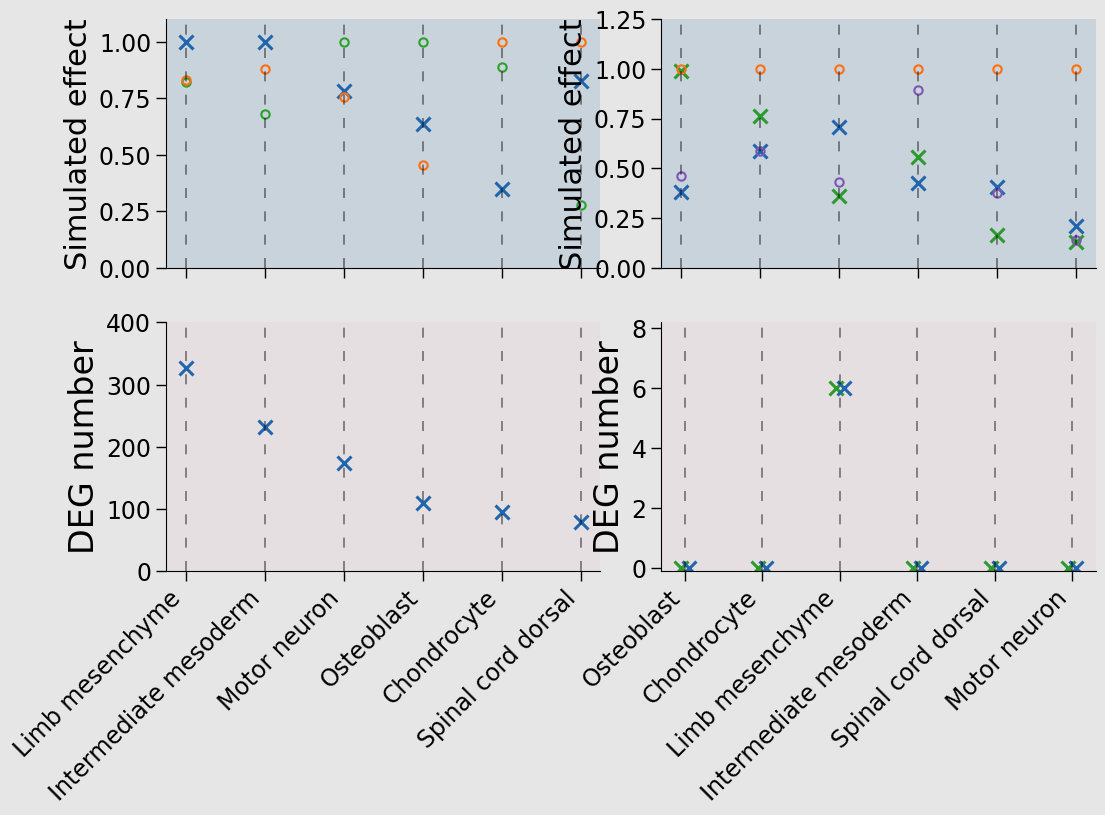

In [5]:
left_order = [
    'Limb#mesenchyme#trajectory',
    'Intermediate#mesoderm#trajectory',
    'Motor#neuron#trajectory',
    'Osteoblast#trajectory',
    'Chondrocyte#trajectory',
    'Spinal#cord#dorsal#trajectory',
]
right_order = [
    'Osteoblast#trajectory',
    'Chondrocyte#trajectory',
    'Limb#mesenchyme#trajectory',
    'Intermediate#mesoderm#trajectory',
    'Spinal#cord#dorsal#trajectory',
    'Motor#neuron#trajectory',
]
label_map = {
    'Limb#mesenchyme#trajectory': 'Limb mesenchyme',
    'Intermediate#mesoderm#trajectory': 'Intermediate mesoderm',
    'Motor#neuron#trajectory': 'Motor neuron',
    'Osteoblast#trajectory': 'Osteoblast',
    'Chondrocyte#trajectory': 'Chondrocyte',
    'Spinal#cord#dorsal#trajectory': 'Spinal cord dorsal',
}

gli_idx = gli_panel.set_index('cell_type')
scn_idx = scn_panel.set_index('cell_type')
gli_left = gli_idx.loc[left_order]
scn_right = scn_idx.loc[right_order]

left_plot_tbl = pd.DataFrame({
    'cell_type': left_order,
    'label': [label_map[c] for c in left_order],
    'Gli1_normalized': gli_left['Gli1_normalized'].values,
    'Gli2_normalized': gli_left['Gli2_normalized'].values,
    'Gli3_normalized': gli_left['Gli3_normalized'].values,
    'deg_count': gli_left['deg_count'].values,
})
right_plot_tbl = pd.DataFrame({
    'cell_type': right_order,
    'label': [label_map[c] for c in right_order],
    'Scn10a_normalized': scn_right['Scn10a_normalized'].values,
    'Scn11a_normalized': scn_right['Scn11a_normalized'].values,
    'Scn9a_normalized': scn_right['Scn9a_normalized'].values,
    'Scn7a_normalized': scn_right['Scn7a_normalized'].values,
    'deg_count': scn_right['deg_count'].values,
})
left_plot_tbl.to_csv(TABLE_DIR / '01_panel_ij_left_plot_table.csv', index=False)
right_plot_tbl.to_csv(TABLE_DIR / '01_panel_ij_right_plot_table.csv', index=False)

x_left = np.arange(len(left_order))
x_right = np.arange(len(right_order))

fig, axs = plt.subplots(2, 2, figsize=(12.0, 8.0), gridspec_kw={'hspace': 0.22, 'wspace': 0.14})
(ax_tl, ax_tr), (ax_bl, ax_br) = axs

for ax in [ax_tl, ax_tr]:
    ax.set_facecolor('#c9d3dc')
for ax in [ax_bl, ax_br]:
    ax.set_facecolor('#e6dfe1')

ax_tl.plot(x_left, gli_left['Gli1_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#2ca02c')
ax_tl.plot(x_left, gli_left['Gli2_normalized'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
ax_tl.plot(x_left, gli_left['Gli3_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#ff6f0e')
for x in x_left:
    ax_tl.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_tl.set_ylim(0, 1.1)
ax_tl.set_ylabel('Simulated effect', fontsize=22)
ax_tl.set_xticks(x_left)
ax_tl.set_xticklabels([])

ax_tr.plot(x_right, scn_right['Scn10a_normalized'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2c9a2c')
ax_tr.plot(x_right, scn_right['Scn11a_normalized'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
ax_tr.plot(x_right, scn_right['Scn9a_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#ff6f0e')
ax_tr.plot(x_right, scn_right['Scn7a_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#7e56b4')
for x in x_right:
    ax_tr.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_tr.set_ylim(0, 1.25)
ax_tr.set_ylabel('Simulated effect', fontsize=22)
ax_tr.set_xticks(x_right)
ax_tr.set_xticklabels([])

ax_bl.plot(x_left, gli_left['deg_count'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
for x in x_left:
    ax_bl.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_bl.set_ylim(0, 400)
ax_bl.set_ylabel('DEG number', fontsize=24)
ax_bl.set_xticks(x_left)
ax_bl.set_xticklabels([label_map[c] for c in left_order], rotation=45, ha='right', fontsize=16)

ax_br.plot(x_right - 0.05, scn_right['deg_count'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2c9a2c')
ax_br.plot(x_right + 0.05, scn_right['deg_count'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
for x in x_right:
    ax_br.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_br.set_ylim(-0.1, 8.2)
ax_br.set_ylabel('DEG number', fontsize=24)
ax_br.set_xticks(x_right)
ax_br.set_xticklabels([label_map[c] for c in right_order], rotation=45, ha='right', fontsize=16)

for ax in [ax_tl, ax_tr, ax_bl, ax_br]:
    ax.tick_params(axis='both', labelsize=17, width=1.0, length=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.subplots_adjust(top=0.94, bottom=0.25)
fig.patch.set_facecolor('#e6e6e6')

panel_out = FIG_DIR / '01_simulation_experimental_panel_ij.png'
fig.savefig(panel_out, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## How to read the comparison
- **GLI family trend**: Lineages with stronger simulated `Gli2` impact generally show larger experimental `Gli2` KO DEG burden.
- **Compensation logic**: Where simulated `Gli1/Gli3` signals are relatively strong, KO severity can be buffered, consistent with paralog compensation.
- **SCN family contrast**: Low DEG burden for `Scn10a/Scn11a`-related KO contexts alongside stronger alternative SCN-family signals is consistent with buffering by paralogs such as `Scn9a`.
- **Practical takeaway**: Lineage context shapes how strongly a gene-family perturbation propagates to transcriptome-scale disruption.